In [67]:
import json
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
def get_name_from_path(path):
    """
    Extracts the name from the given path.
    """
    return path.split("/")[1].replace("infinite-bench-result-", "")

DIRS = [
  "./infinite-bench-result-mistral-weighted",
  "./infinite-bench-result-qwen4b",
  "./infinite-bench-result-qwen4b-weighted",
  "./infinite-bench-result-llama8b",
  "./infinite-bench-result-llama8b-weighted",
  "./infinite-bench-result-mistral",
]

FILES_PER_DIR = [
  "code_debug.jsonl",
  "number_string.jsonl",
  "kv_retrieval.jsonl",
  "passkey.jsonl",
  "longbook_choice_eng.jsonl",
  "result.json",
  "math_find.jsonl"
]

contents = {}


for d in DIRS:
    for f in FILES_PER_DIR:
        file_path = f"{d}/{f}"
        assert os.path.exists(file_path)

        with open(file_path, "r") as file:
            content = file.read()
            if file_path.endswith(".jsonl"):
                # if it's a JSONL file, split by lines and parse each line

                lines = content.splitlines()
                contents[file_path] = [json.loads(line) for line in lines if line.strip()]
            else:
                # if it's a JSON file, parse the entire content
                contents[file_path] = json.loads(content)

In [56]:
def load_results_df():
    df = None
    for file_path, data in contents.items():
        if file_path.endswith("result.json"):
            if df is None:
                df = pd.DataFrame(data, index=[0])
                df["model"] = get_name_from_path(file_path)
            else:
                temp_df = pd.DataFrame(data, index=[0])
                temp_df["model"] = get_name_from_path(file_path)
                df = pd.concat([df, temp_df], ignore_index=True)
    return df

def load_df(task):
    df = None
    for file_path, data in contents.items():
        if task in file_path:
            if df is None:
                df = pd.DataFrame(data)
                df["model"] = get_name_from_path(file_path)
            else:
                temp_df = pd.DataFrame(data)
                temp_df["model"] = get_name_from_path(file_path)
                df = pd.concat([df, temp_df], ignore_index=True)

    return df


df_code_debug = load_df("code_debug")
df_kv_retrieval = load_df("kv_retrieval")
df_longbook_choice_eng = load_df("longbook_choice_eng")
df_math_find = load_df("math_find")
df_number_string = load_df("number_string")
df_passkey = load_df("passkey")
df_result = load_results_df()

In [ ]:
print(result_df.to_latex(index=False, float_format="%.3f", escape=False))

\begin{tabular}{rrrrrrl}
\toprule
code_debug & math_find & number_string & kv_retrieval & longbook_choice_eng & passkey & model \\
\midrule
28.170 & 25.430 & 99.830 & 90.400 & 41.050 & 100.000 & mistral-weighted \\
23.320 & 21.710 & 100.000 & 17.000 & 38.930 & 100.000 & qwen4b \\
22.540 & 21.710 & 100.000 & 29.600 & 38.260 & 100.000 & qwen4b-weighted \\
29.700 & 17.140 & 96.270 & 3.800 & 41.920 & 100.000 & llama8b \\
28.930 & 20.000 & 98.310 & 3.200 & 40.610 & 100.000 & llama8b-weighted \\
26.650 & 26.860 & 99.660 & 92.800 & 41.480 & 100.000 & mistral \\
\bottomrule
\end{tabular}



In [61]:
def get_incorrect_answers(df):
  """check if pred contains the answer string"""
  
  # if pred is a len 2 array, it is multiple choice and the 
  # second element is the answer. Otherwise, it is a string
  for i, row in df.iterrows():
    if isinstance(row["answers"], list) and len(row["answers"]) == 2:
      df.at[i, "incorrect"] = str(row["answers"][1]) not in row["pred"]
    else:
      df.at[i, "incorrect"] = str(row["answers"][0]) not in row["pred"]

  return df[df["incorrect"] == True].reset_index(drop=True)

get_incorrect_answers(df_code_debug)
get_incorrect_answers(df_kv_retrieval)
get_incorrect_answers(df_longbook_choice_eng)
get_incorrect_answers(df_math_find)
get_incorrect_answers(df_number_string)
get_incorrect_answers(df_passkey)

,pred,answers,all_classes,length,token_length,model,incorrect


In [ ]:
def plot_distribution_correct_by_model(df, task):
    """
    Plot the percentage of correct answers by model for a given task.
    """
    df["incorrect"] = df["incorrect"].astype(bool)
    correct_pct = (
        df.groupby("model")["incorrect"]
        .apply(lambda x: 100 * (~x).sum() / len(x))
        .reset_index(name="percent_correct")
    )
    plt.figure(figsize=(10, 6))
    sns.barplot(data=correct_pct, x="model", y="percent_correct", order=correct_pct.sort_values("percent_correct", ascending=False)["model"])
    plt.title(f"Percentage of Correct Answers by Model for {task}")
    plt.xlabel("Model")
    plt.ylabel("Percent Correct")
    plt.ylim(0, 100)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

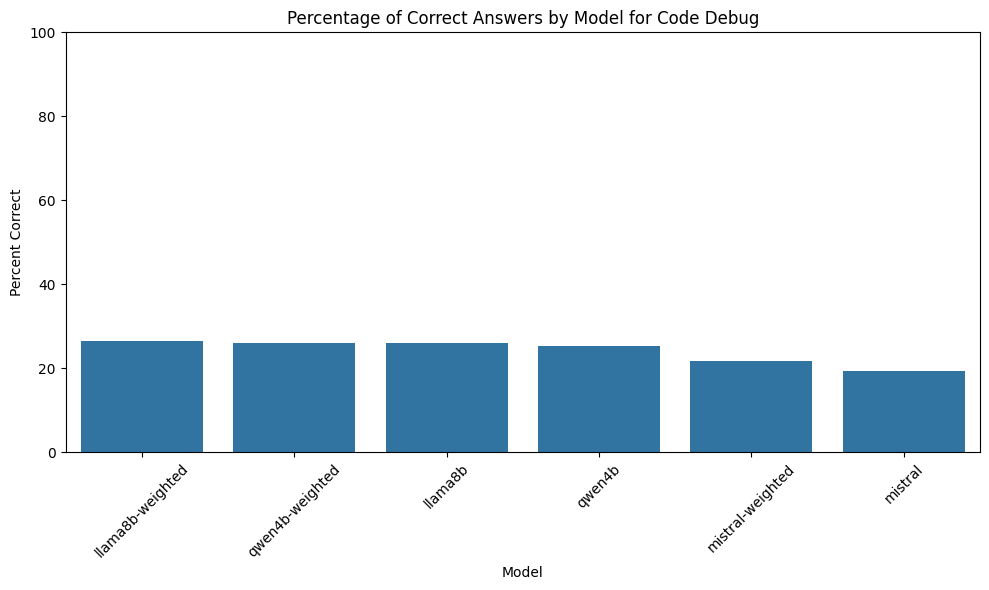

In [78]:
plot_distribution_correct_by_model(df_code_debug, "Code Debug")


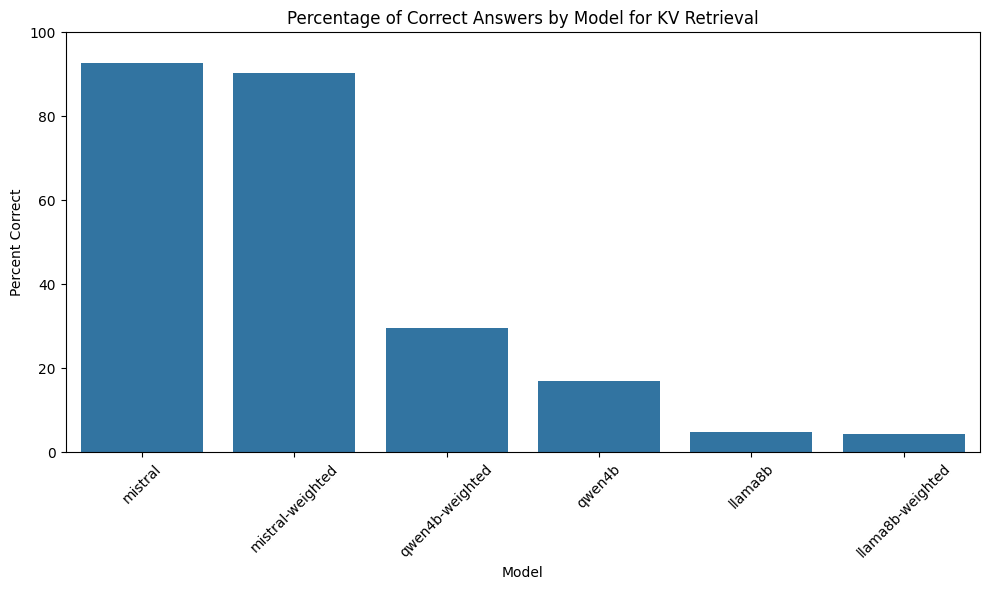

In [79]:
plot_distribution_correct_by_model(df_kv_retrieval, "KV Retrieval")

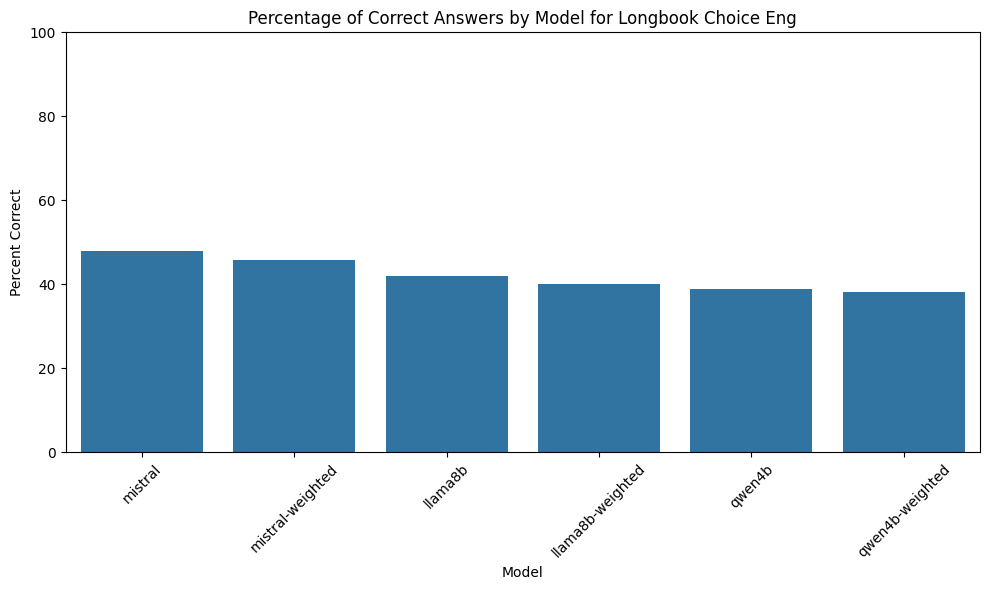

In [80]:
plot_distribution_correct_by_model(df_longbook_choice_eng, "Longbook Choice Eng")

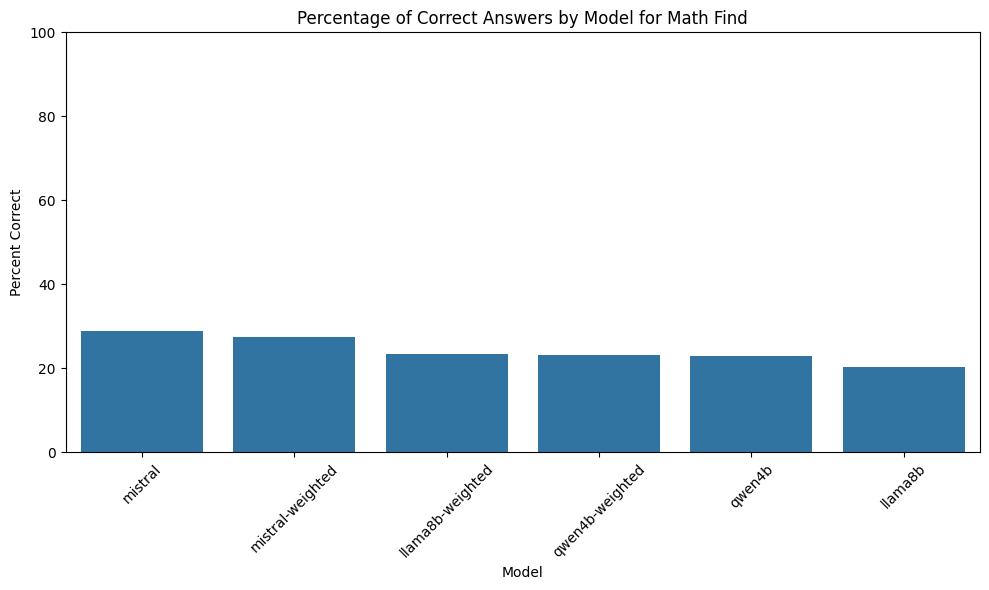

In [81]:
plot_distribution_correct_by_model(df_math_find, "Math Find")


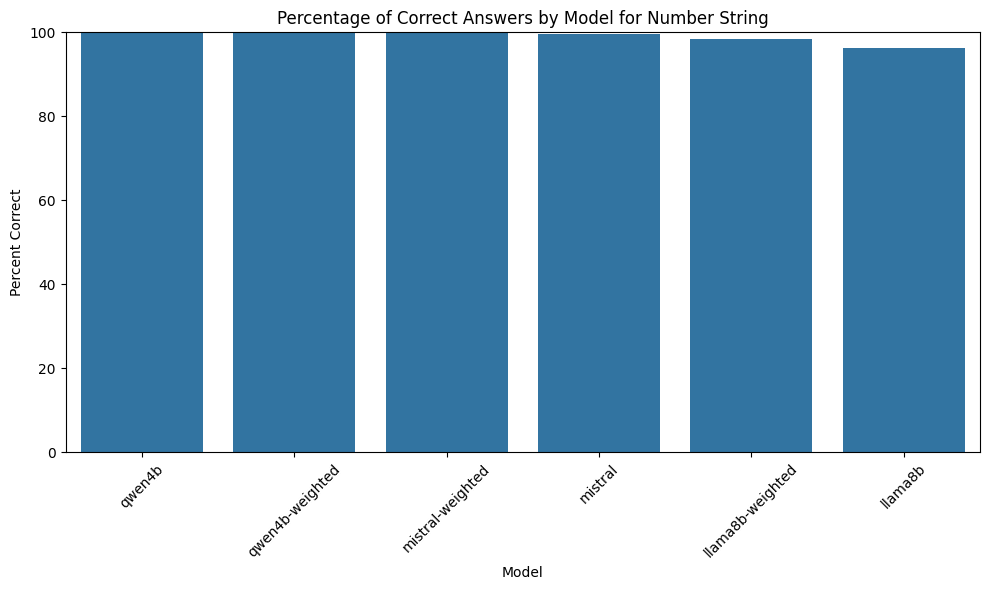

In [82]:
plot_distribution_correct_by_model(df_number_string, "Number String")


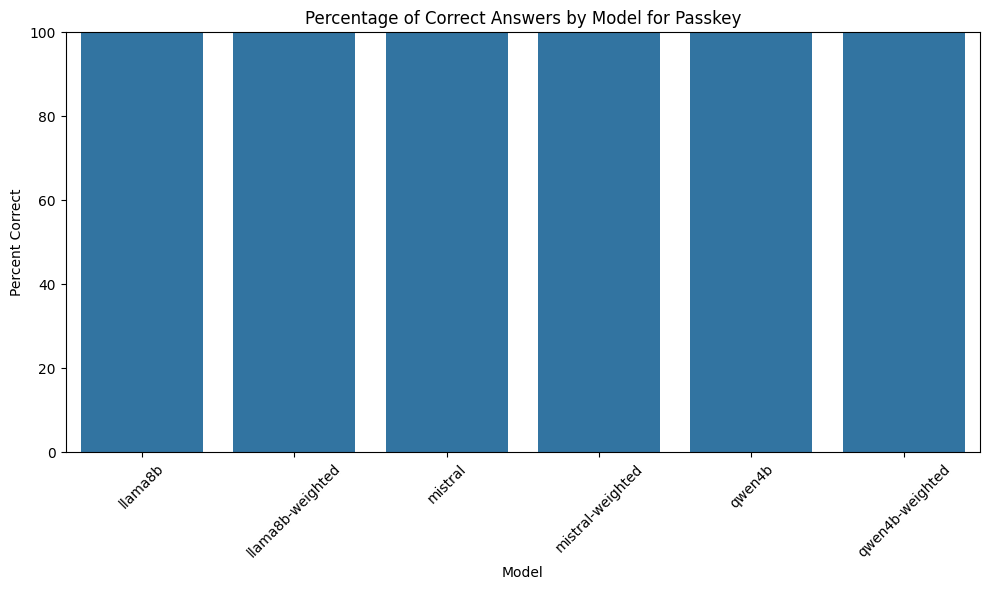

In [83]:
plot_distribution_correct_by_model(df_passkey, "Passkey")

In [ ]:
def add_partial_correctness_lengths(df):
    df["match_length"] = 0

    for i, row in df.iterrows():
        if isinstance(row["pred"], list):
            pred = row["pred"][0]
        else:
            pred = row["pred"]

        if isinstance(row["answers"], list):
            answer = row["answers"][0]
        else:
            answer = row["answers"]

        if row["incorrect"] == False:
            # for correct answers, match_length = full answer length
            df.at[i, "match_length"] = len(str(answer))
        else:
            # for incorrect answers, find the longest matching prefix
            pred_str = str(pred)
            answer_str = str(answer)

            match_length = 0
            best = 0

            for c in pred_str:
                if match_length >= len(answer_str):
                    break
                if c == answer_str[match_length]:
                    match_length += 1
                else:
                    best = max(best, match_length)
                    match_length = 0

            best = max(best, match_length)

            df.at[i, "match_length"] = best


def plot_partial_correctness_distribution(df, task):

    plt.figure(figsize=(12, 8))

    models = df["model"].unique()
    n_models = len(models)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for i, model in enumerate(models):
        row = i // n_cols
        col = i % n_cols

        model_data = df[df["model"] == model]

        axes[row, col].hist(
        model_data["match_length"], bins=20, alpha=0.7, edgecolor="black"
    )
        axes[row, col].set_title(f"{model}\n(n={len(model_data)})")
        axes[row, col].set_xlabel("Match Length")
        axes[row, col].set_ylabel("Frequency")
        axes[row, col].grid(True, alpha=0.3)

    for i in range(len(models), n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        fig.delaxes(axes[row, col])

    plt.tight_layout()
    plt.suptitle(f"Distribution of Match Lengths by Model for {task}", y=1.02, fontsize=16)
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="model", y="match_length")
    plt.xticks(rotation=45)
    plt.title(f"Match Length Distribution by Model for {task}")
    plt.xlabel("Model")
    plt.ylabel("Match Length")
    plt.tight_layout()
    plt.show()

<Figure size 1200x800 with 0 Axes>

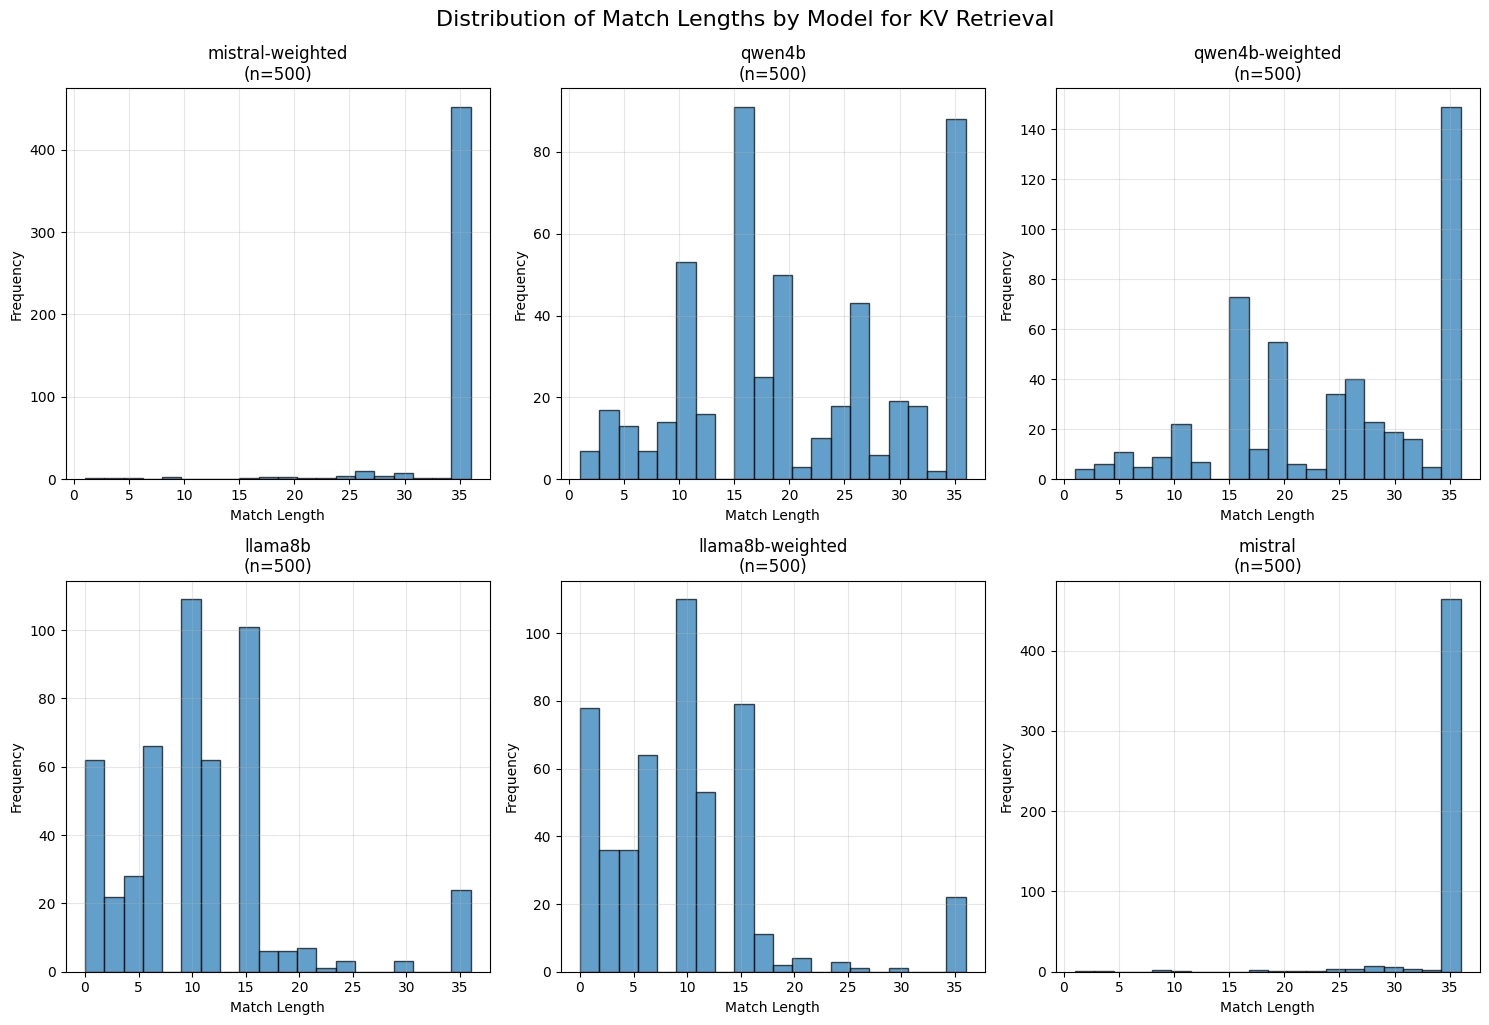

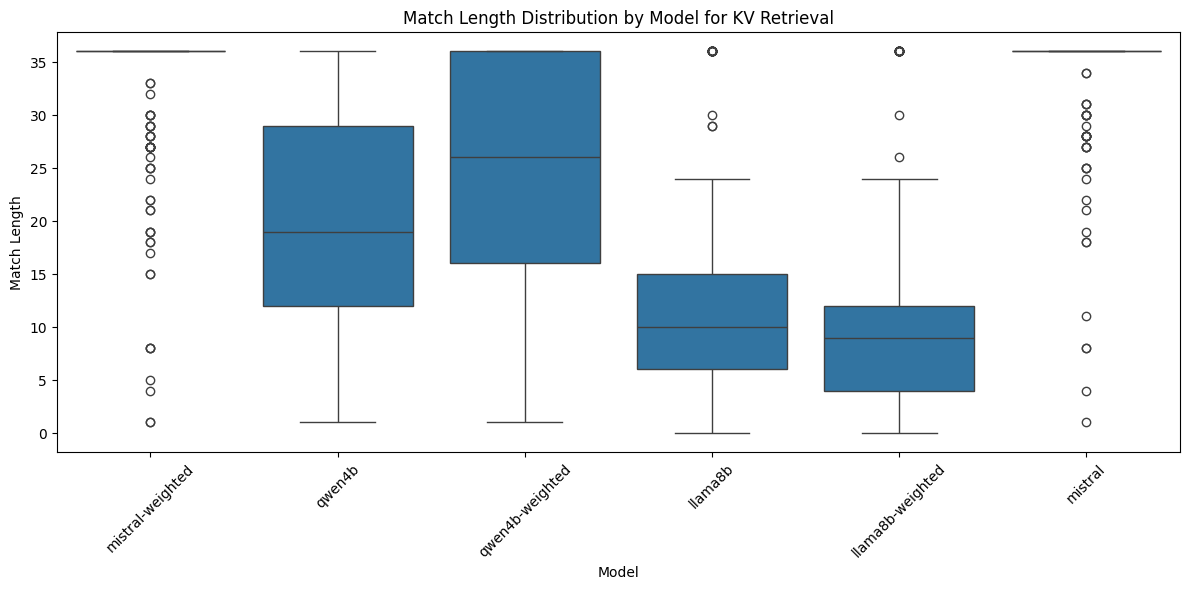

In [108]:
add_partial_correctness_lengths(df_kv_retrieval)
plot_partial_correctness_distribution(df_kv_retrieval, "KV Retrieval")

<Figure size 1200x800 with 0 Axes>

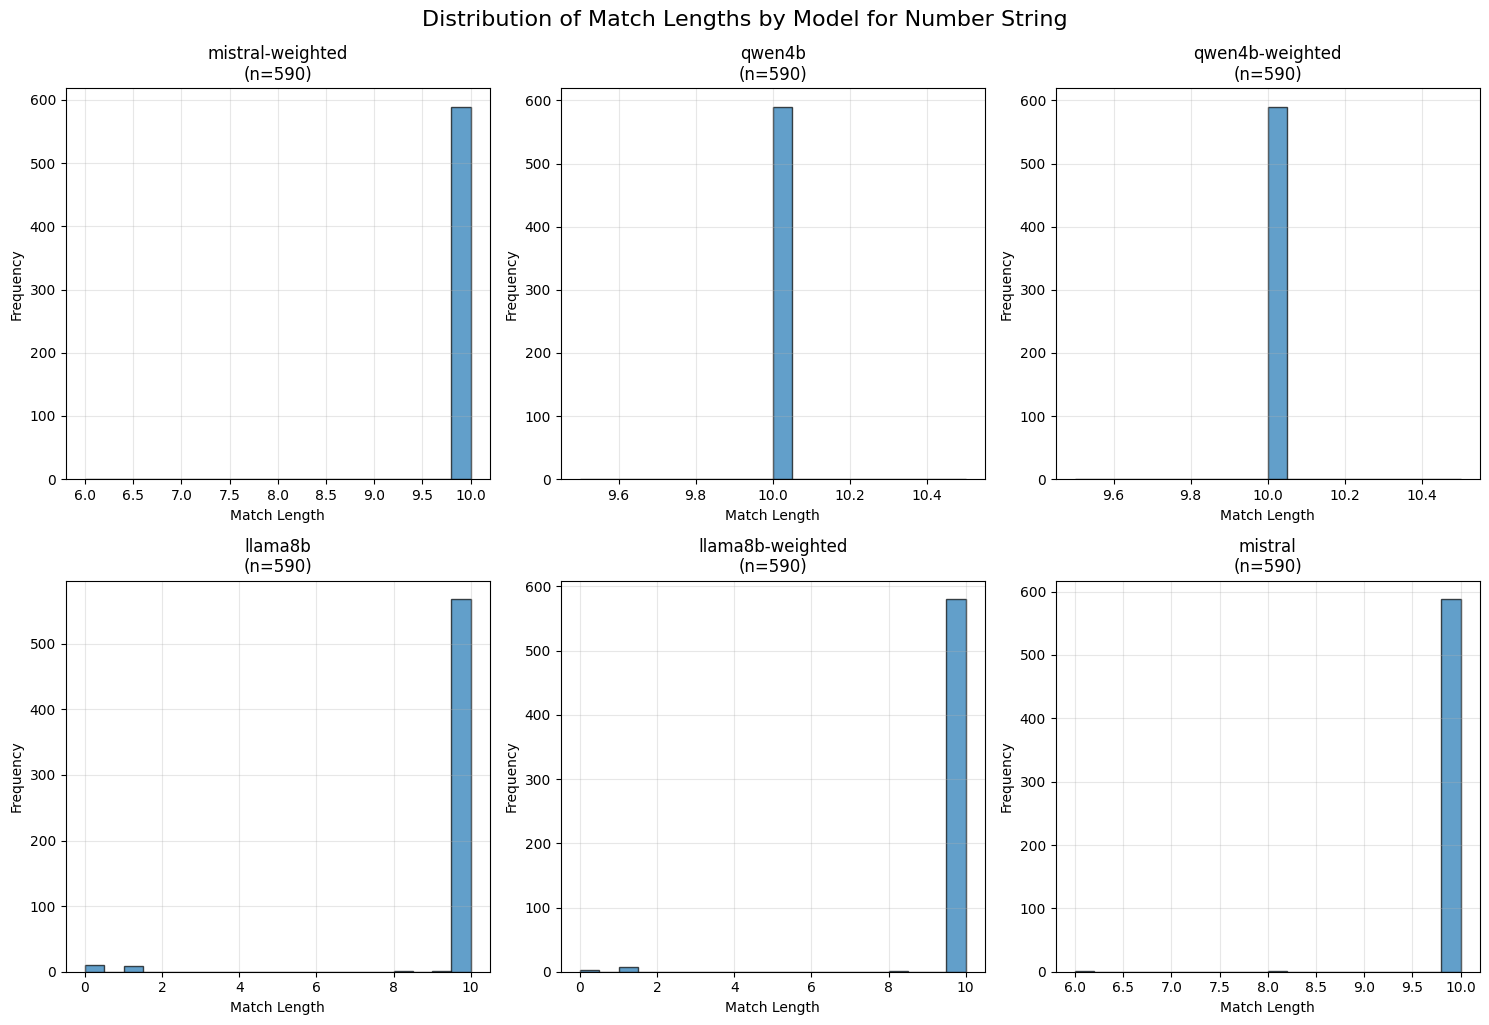

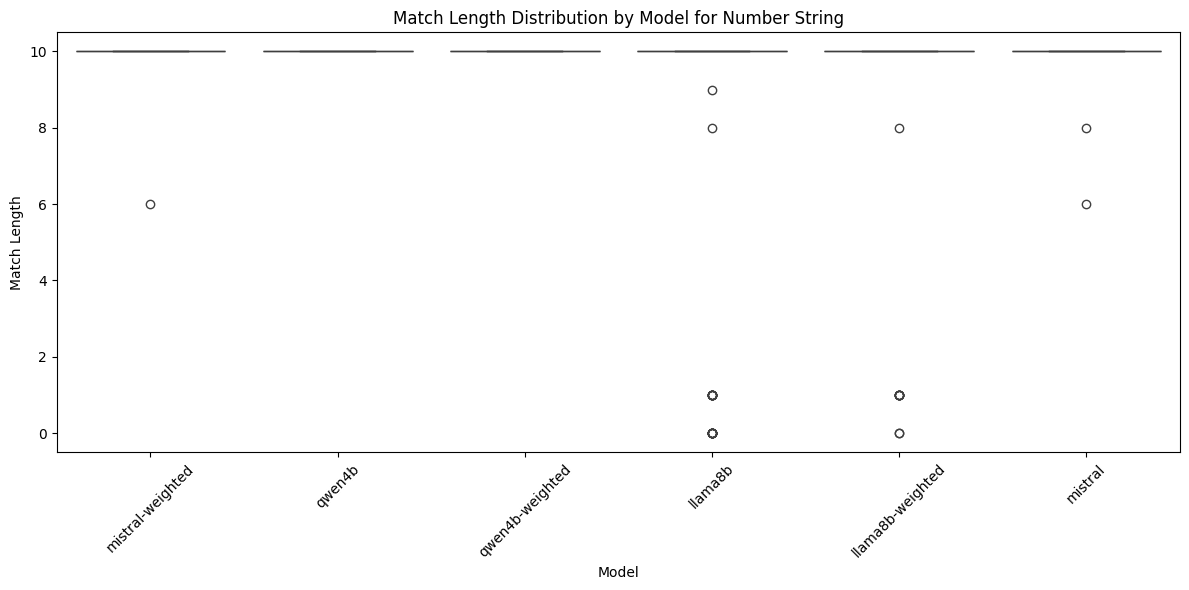

In [109]:
add_partial_correctness_lengths(df_number_string)
plot_partial_correctness_distribution(df_number_string, "Number String")

<Figure size 1200x800 with 0 Axes>

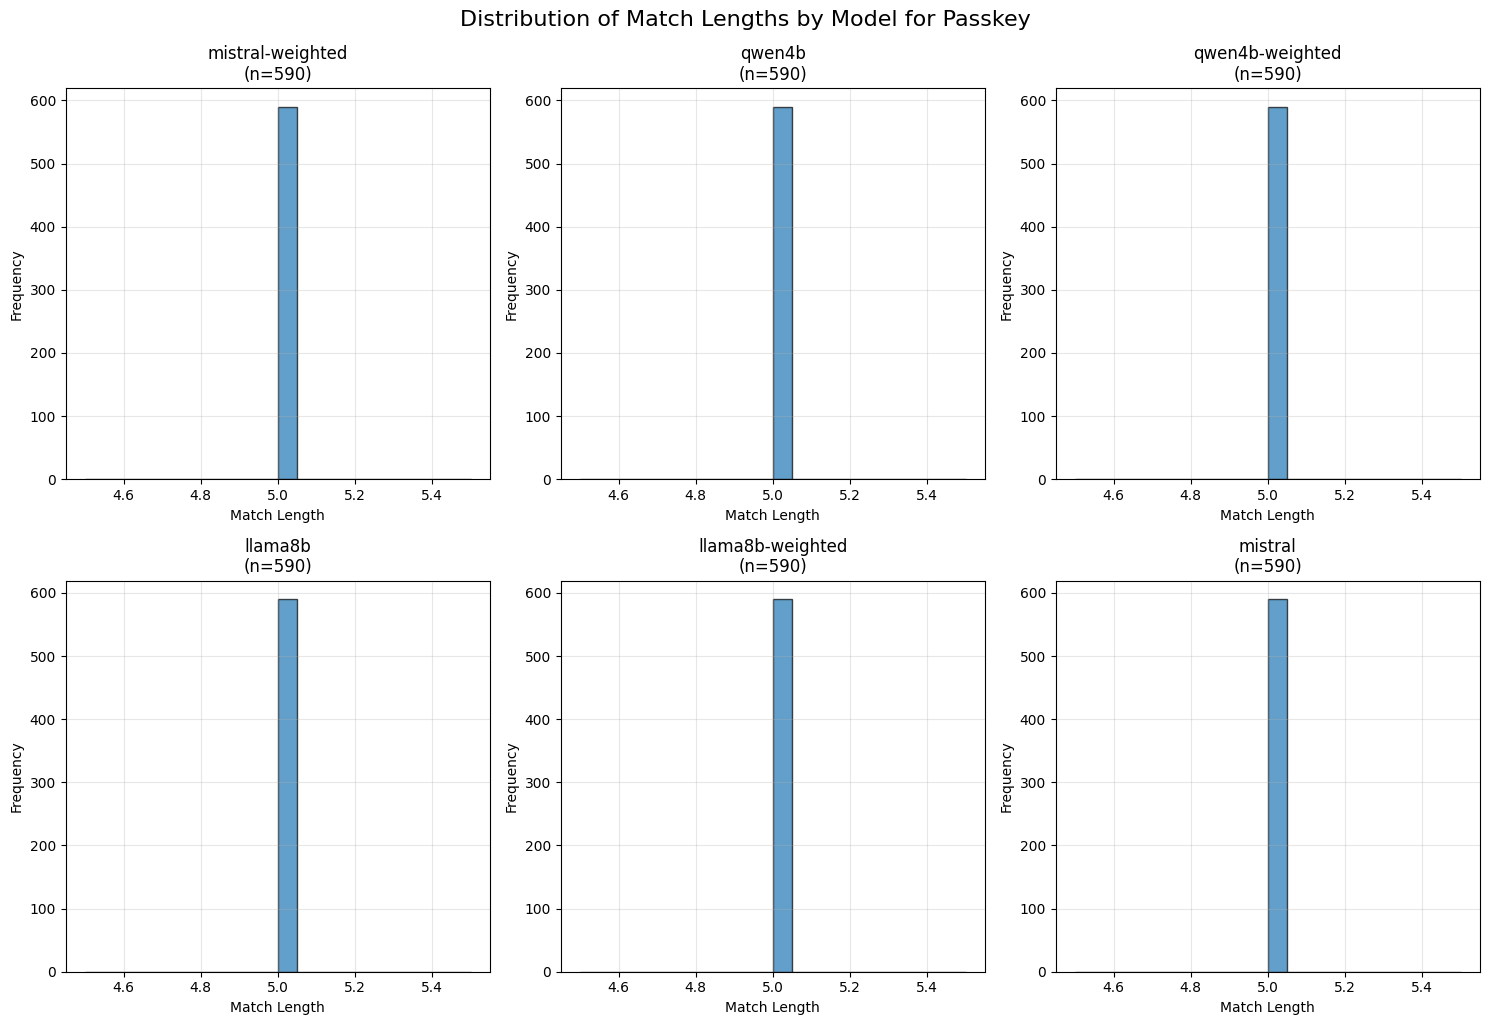

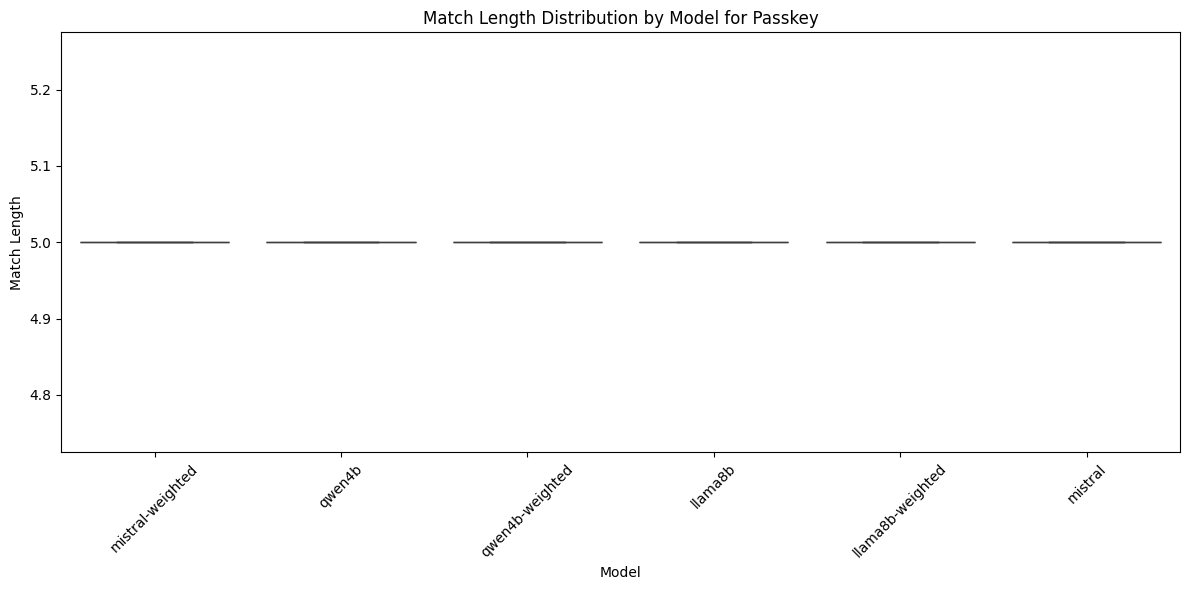

In [110]:
add_partial_correctness_lengths(df_passkey)
plot_partial_correctness_distribution(df_passkey, "Passkey")

In [ ]:
print(df_result.to_latex(
    index=False,
))

\begin{tabular}{rrrrrrl}
\toprule
code_debug & math_find & number_string & kv_retrieval & longbook_choice_eng & passkey & model \\
\midrule
28.170000 & 25.430000 & 99.830000 & 90.400000 & 41.050000 & 100.000000 & mistral-weighted \\
23.320000 & 21.710000 & 100.000000 & 17.000000 & 38.930000 & 100.000000 & qwen4b \\
22.540000 & 21.710000 & 100.000000 & 29.600000 & 38.260000 & 100.000000 & qwen4b-weighted \\
29.700000 & 17.140000 & 96.270000 & 3.800000 & 41.920000 & 100.000000 & llama8b \\
28.930000 & 20.000000 & 98.310000 & 3.200000 & 40.610000 & 100.000000 & llama8b-weighted \\
26.650000 & 26.860000 & 99.660000 & 92.800000 & 41.480000 & 100.000000 & mistral \\
\bottomrule
\end{tabular}



In [ ]:
"""
\begin{table}[h]
\centering
\caption{$\infty$-Bench Results }
\begin{tabular}{lcccccc}
\toprule
\textbf{Model} & \textbf{Code} & \textbf{Math} & \textbf{Num Str} & \textbf{KV Ret} & \textbf{Long Choice} & \textbf{Pass} \\
\midrule
\multicolumn{7}{c}{\textbf{Reproduction Results}} \\
\midrule
InfLLM (qwen4b-weighted)    & 22.5  & 21.7  & 100.0 & 29.6  & 38.3  & 100.0 \\
InfLLM (qwen4b)             & 23.3  & 21.7  & 100.0 & 17.0  & 38.9  & 100.0 \\
InfLLM (llama8b)            & 29.7  & 17.1  & 96.3  & 3.8   & 41.9  & 100.0 \\
InfLLM (llama8b-weighted)   & 28.9  & 20.0  & 98.3  & 3.2   & 40.6  & 100.0 \\
InfLLM (mistral)            & 26.7  & 26.9  & 99.7  & 92.8  & 41.5  & 100.0 \\
InfLLM (mistral-weighted)   & 28.2  & 25.4  & 99.8  & 90.4  & 41.1  & 100.0 \\
\midrule
\multicolumn{7}{c}{\textbf{Mistral-based Models (7B)}} \\
\midrule
Mistral                     & 28.8  & 20.6 & 28.8   & 14.8  & 44.5  & 25.2 \\
NTK                         & 100.0 & 26.9 & 86.8   & 19.2  & 40.2  & 44.3 \\
SelfExtend                  & 100.0 & 19.1 & 100.0  & 15.6  & 42.8  & 44.8 \\
Infinite                    & 28.8  & 16.3 & 28.8   & 0.4   & 42.8  & 21.6 \\
Streaming                   & 28.8  & 16.9 & 28.5   & 0.2   & 42.4  & 21.5 \\
H2O                         & 8.6   & 26.9 & 4.8    & 2.6   & 48.0  & 18.7 \\
\midrule
InfLLM                      & 100.0 & 25.7 & 96.1   & 96.8  & 43.7  & 57.7 \\
\midrule
\multicolumn{7}{c}{\textbf{Llama-3-based Models (8B)}} \\
\midrule
Llama-3                     & 8.5   & 21.7  & 7.8   & 6.2   & 44.1  & 18.4 \\
NTK                         & 0.0   & 2.6   & 0.0   & 0.0   & 0.0   & 1.3 \\
SelfExtend                  & 100.0 & 22.6  & 100.0 & 0.2   & 19.7  & 38.0 \\
Infinite                    & 6.8   & 20.6  & 7.6   & 0.2   & 41.5  & 16.0 \\
Streaming                   & 8.5   & 21.4  & 8.3   & 0.4   & 40.6  & 16.3 \\
H2O                         & 2.5   & 6.0   & 2.4   & 0.0   & 0.0   & 2.1 \\
\midrule
InfLLM                      & 100.0 & 23.7 & 99.0 & 5.0 & 43.7 & 45.0 \\
\bottomrule
\end{tabular}
\end{table}

"""